# 국내 자산배분 최신 실험: Open Asset Pricing 입력변수와 기존 전략 합성

이 노트북은 최신 실험인 **KRX 업종지수 기반 Open Asset Pricing(OAP) 신호 추가 실험**을 설명하고, 저장된 결과를 시각화하며, Google Colab에서 전체 실험을 그대로 재실행합니다.

## 핵심 결론

- 균형형 최종 후보: **`SelectedMediumHorizonOAPVol15`**
- 구성: 기존 FinalBlend 자산배분 + 국내 OAP 입력으로 예측한 **향후 2개월 경로손실 -5% 위험 오버레이** + 연 15% 변동성 타기팅
- 전체 2007-04~2026-07: CAGR **14.95%**, Sharpe **1.059**, MDD **-12.98%**
- 잠금 검증 2018-01~2026-07: CAGR **17.86%**, Sharpe **1.211**, MDD **-12.56%**
- 비교 기준 `ExistingStructureVol15`보다 전체 기간 CAGR +0.09%p, Sharpe +0.009, MDD +0.06%p 개선
- 다만 잠금구간 부트스트랩에서 Sharpe 개선 확률은 **73.5%**이고 90% 구간이 0을 포함하므로, 개선이 통계적으로 확정됐다고 볼 수는 없습니다.

> 역사적 시뮬레이션이며 미래 성과를 보장하지 않습니다. Sharpe의 무위험수익률은 0%입니다.

## Colab에서 실행하는 법

1. 이 노트북과 `openassetpricing_latest_colab_bundle.zip`을 내려받습니다.
2. 노트북을 Google Colab에서 엽니다.
3. **런타임 → 모두 실행**을 누릅니다.
4. 업로드 창이 뜨면 ZIP 파일을 선택합니다.

전체 재실행이 기본값입니다. 결과는 `/content/RegimeDecisionTest/results/`에 저장됩니다.

## 1. 이번 실험에서 답하는 질문

이번 실험은 앞선 피드백을 다음 순서로 검증합니다.

| 질문 | 구현 |
|---|---|
| Regime-aware 모델의 추가 입력이 도움이 되는가? | 국내 기본 위험변수에 OAP 가격·거래량 합성지표를 추가 |
| 국장 타깃에 SPY·VIX가 적절한가? | 최종 OAP 사양에서는 **SPY·VIX를 제외**하고 KOSPI200·KRX 업종지수만 사용 |
| 2005년부터 볼 수 있는가? | 원자료와 일부 팩터는 2005년부터 준비하되, OAP 3년 워밍업과 공통 자산수익률 때문에 최종 공통 성과는 2007-04부터 시작 |
| 2007~2026 성과는 어떠한가? | 전체 2007-04~2026-07 및 네 하위기간을 별도 계산 |
| `지수×거래량`을 대용치로 쓰면? | KOSPI200 지수값×거래량을 거래대금 대용치로 추가한 후보를 별도 비교 |
| 기존 전략과 합성하면? | 공동학습, 확률합성, 추세 오버라이드, 위험위원회, 중기 손실 오버레이를 모두 비교 |

중요한 점은 미국 개별주 OAP 신호를 그대로 복제한 것이 아니라, **국내 업종지수 횡단면으로 번역한 시장상태 아날로그**라는 것입니다.

## 2. Colab 환경과 재현 번들 준비

Colab에서는 CPU 런타임이면 충분합니다. 번들에는 실행 소스, 한국 거시자료, KRX 지수 데이터베이스, 시장가격 캐시, 기존 전략 팩터, 최신 결과가 들어 있습니다. 따라서 ZIP 업로드 이후에는 외부 시세 다운로드 없이 재현할 수 있습니다.

In [1]:
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy>=1.26", "pandas>=2.1", "scipy>=1.11",
        "scikit-learn>=1.4", "lightgbm>=4.3", "hmmlearn>=0.3.2",
        "openpyxl>=3.1", "matplotlib>=3.8",
        "koreanize-matplotlib>=0.1.1",
    ])
    print("Colab 의존성 설치 완료")
else:
    print("로컬 Python 환경 사용")

로컬 Python 환경 사용


In [2]:
from pathlib import Path
import os
import zipfile

PROJECT_ROOT = Path("/content/RegimeDecisionTest") if IN_COLAB else Path.cwd()
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

def project_ready(root: Path) -> bool:
    required = [
        root / "strategies/stage05_openassetpricing/openassetpricing_signal_experiment.py",
        root / "raw_data" / "compass.db",
        root / "raw_data" / "krx_bond_index.csv",
        root / "cache" / "market_daily.csv",
        root / "results" / "hard_crash_features.csv",
        root / "results" / "market_structure_composites.csv",
        root / "results" / "market_structure_loss3_composite_domestic_factor.csv",
        root / "results" / "market_structure_loss3_composite_plus_index_volume_domestic_factor.csv",
        root / "results" / "openassetpricing_validation.json",
    ]
    return all(path.exists() for path in required)

def safe_extract(archive_path: Path, destination: Path) -> None:
    destination = destination.resolve()
    with zipfile.ZipFile(archive_path) as archive:
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if target != destination and destination not in target.parents:
                raise ValueError(f"안전하지 않은 ZIP 경로: {member.filename}")
        archive.extractall(destination)

if not project_ready(PROJECT_ROOT):
    if not IN_COLAB:
        raise FileNotFoundError("프로젝트 파일 또는 openassetpricing_latest_colab_bundle.zip이 필요합니다.")
    from google.colab import files
    print("openassetpricing_latest_colab_bundle.zip을 업로드하세요.")
    uploaded = files.upload()
    zip_names = [name for name in uploaded if name.lower().endswith(".zip")]
    if len(zip_names) != 1:
        raise ValueError("재현 번들 ZIP 하나를 업로드해야 합니다.")
    safe_extract(Path(zip_names[0]), PROJECT_ROOT)

if not project_ready(PROJECT_ROOT):
    raise FileNotFoundError("ZIP에서 필수 실행파일 또는 데이터를 찾지 못했습니다.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS = PROJECT_ROOT / "results"
print("프로젝트 폴더:", PROJECT_ROOT)
print("최신 검증파일:", RESULTS / "openassetpricing_validation.json")

프로젝트 폴더: D:\Programming\python_example\RegimeDecisionTest
최신 검증파일: D:\Programming\python_example\RegimeDecisionTest\results\openassetpricing_validation.json


In [3]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import Markdown, display

if IN_COLAB:
    import koreanize_matplotlib  # noqa: F401
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

CAL_END = pd.Period("2017-12", "M")
LOCKED_START = pd.Period("2018-01", "M")
print("분석 환경 준비 완료")

분석 환경 준비 완료


## 3. 데이터 계보와 시점 통제

분석 흐름은 다음과 같습니다.

`KRX 일별 종가·거래량 → 월초 이전 데이터만 절단 → OAP 월별 특징 → 국내 기본 위험변수와 결합 → 확장창 학습 → 위험 오버레이 → 월별 자산배분 → 거래비용 차감`

시점 통제의 핵심은 세 가지입니다.

1. 목표 월의 특징은 그 달 시작 **최소 2일 전**까지만 계산합니다.
2. 향후 2개월 손실을 예측할 때 학습 끝에서 **2개월 label embargo**를 적용해 겹치는 미래수익률이 들어오지 않게 합니다.
3. 입력 조합·목표기간·손실 임계값·방어 이동 한도는 2017-12까지만 선택하고, 2018-01 이후는 잠금 검증으로 남깁니다.

원자료는 2005년 이전부터 존재하지만 OAP의 장기반전·3년 워밍업과 모든 자산의 공통 수익률을 맞추면 비교 가능한 백테스트 시작일은 **2007-04**입니다. 2005-01~2007-03을 억지로 채우지 않는 것이 결측을 미래정보나 다른 표본으로 대체하는 것보다 안전합니다.

## 4. OAP 신호를 국내 업종지수로 번역한 방법

원 아이디어는 [Open Asset Pricing SignalDoc Browser](https://openassetpricing.com/SignalDoc-Browser.html)에서 가져왔습니다.

| 합성지표 | OAP 아이디어 | 국내 구현 |
|---|---|---|
| 모멘텀·추세 | Mom12m, Mom6m, IntMom, High52, IndMom, MomVol | KRX 업종 12/6/중기 모멘텀 중앙값, 52주 고점 거리, 상승 업종 비율, 거래대금 가중 업종 모멘텀 |
| 반전·쏠림 | STreversal, MRreversal, LRreversal | 업종 단기·중기·장기 수익률 중앙값과 횡단면 분산 |
| 저위험·꼬리 | RealizedVol, IdioVol3F, MaxRet, ReturnSkew, Beta | 업종 실현변동성, 시장회귀 잔차변동성, 최대 일수익률, 왜도, 베타 평균·분산 |
| 유동성·활동 | Illiquidity, DolVol, VolumeTrend, VolSD | `절대수익률/(지수×거래량)` Amihud 대용치, 거래대금 z-score, 거래량 추세와 변동계수 |

여기서 `지수×거래량`은 실제 거래대금이 아니라 지수 데이터에서 만들 수 있는 **대용치**입니다. 절대 단위보다 동일 계열 내 시간변화와 업종 간 상대순위를 사용합니다. SignalDoc에서 Placebo/Dropped로 분류된 신호는 사전에 제외했습니다.

### 왜 SPY·VIX를 넣지 않았나

최종 OAP 사양은 국장 타깃이므로 SPY·VIX를 쓰지 않습니다. 글로벌 위험전염을 설명할 가능성은 있지만, 국내 가격·거래량 신호의 순수한 추가효과를 측정하는 이번 질문에서는 혼입변수가 됩니다. 따라서 국내 기본 특징과 KOSPI200·KRX 업종지수만 사용했습니다.

## 5. 모델과 포트폴리오 규칙

선택 전략의 목표변수는 기준 자산배분의 향후 2개월 경로 중 누적손실이 **-5% 아래**로 내려가는 사건입니다.

- 모델: class-balanced logistic regression
- 학습: 최소 표본 이후 매월 확장창 재학습
- 입력: 국내 기본 위험변수 + 네 OAP 합성지표
- 신호: 원시 위험확률을 그 시점까지의 확장 백분위로 변환
- 작동: 위험 백분위 상위 20%에서만 방어 강도를 증가
- 최대 방어 이동: 20%p
- 사후 위험제어: 연 15% 변동성 타기팅
- 비용: 월별 회전율 거래비용, 해외자산 환전비용, 레버리지 조달비용 포함

Logistic을 사용한 이유는 희귀사건 수가 매우 적은 상태에서 복잡한 트리 모델의 자유도를 추가하기보다, 입력변수 추가효과를 더 보수적으로 측정하기 위해서입니다.

## 6. 전체 실험 재실행

아래 셀은 최신 실험 소스를 그대로 실행합니다. 번들에 저장된 결과만 빠르게 확인하려면 `RUN_FULL_EXPERIMENT = False`로 바꾸면 됩니다. 기본값 `True`에서는 Colab의 CPU로 전체 특징 계산, walk-forward 학습, 후보 보정, 잠금 평가, 비용 강건성, 5,000회 블록 부트스트랩을 다시 수행합니다.

In [4]:
RUN_FULL_EXPERIMENT = True

if RUN_FULL_EXPERIMENT:
    command = [
        sys.executable,
        "-u",
        "-m",
        "strategies.stage05_openassetpricing.openassetpricing_signal_experiment",
    ]
    print("실행:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
    print("전체 실험 재실행 완료")
else:
    print("번들에 저장된 최신 결과를 사용합니다.")

실행: D:\Programming\python_example\Arcana\.venv-llama\Scripts\python.exe -u -m strategies.stage05_openassetpricing.openassetpricing_signal_experiment


전체 실험 재실행 완료


## 7. 최신 결과 로딩과 재현성 점검

결과 CSV와 JSON의 기간, 선택 규칙, 결측·무한대 여부를 확인합니다. 이후 표는 하드코딩하지 않고 방금 생성된 파일에서 읽습니다.

In [5]:
comparison = pd.read_csv(RESULTS / "openassetpricing_comparison.csv")
costs = pd.read_csv(RESULTS / "openassetpricing_cost_robustness.csv")
features = pd.read_csv(RESULTS / "openassetpricing_features.csv", parse_dates=["month"]).set_index("month")
composites = pd.read_csv(RESULTS / "openassetpricing_composites.csv", parse_dates=["month"]).set_index("month")
selected_bt = pd.read_csv(RESULTS / "openassetpricing_medium_horizon_backtest.csv", parse_dates=["month"]).set_index("month")
selected_factor = pd.read_csv(RESULTS / "openassetpricing_medium_horizon_factor.csv", parse_dates=["month"]).set_index("month")
medium_grid = pd.read_csv(RESULTS / "openassetpricing_medium_horizon_calibration.csv")
validation = json.loads((RESULTS / "openassetpricing_validation.json").read_text(encoding="utf-8"))

assert validation["selection"]["calibration_end"] == "2017-12"
assert validation["selection"]["locked_start"] == "2018-01"
assert validation["selection"]["medium_horizon_target"] == "oap_path_loss_2m_5"
assert int(validation["selection"]["medium_horizon_months"]) == 2
assert np.isfinite(selected_bt["return"]).all()
assert selected_bt.index.min() == pd.Timestamp("2007-04-01")
assert selected_bt.index.max() == pd.Timestamp("2026-07-01")

audit = pd.DataFrame({
    "값": [
        selected_bt.index.min().strftime("%Y-%m"),
        selected_bt.index.max().strftime("%Y-%m"),
        len(selected_bt),
        validation["selection"]["calibration_end"],
        validation["selection"]["locked_start"],
        validation["selection"]["medium_horizon_target"],
        validation["selection"]["medium_horizon_shift"],
    ]
}, index=["성과 시작", "성과 종료", "월 수", "보정 종료", "잠금 시작", "선택 목표", "최대 방어 이동"])
display(audit)
print("재현성 점검 통과")

,값
성과 시작,2007-04
성과 종료,2026-07
월 수,232
보정 종료,2017-12
잠금 시작,2018-01
선택 목표,oap_path_loss_2m_5
최대 방어 이동,0.2


재현성 점검 통과


## 8. 핵심 성과 비교

`FinalBlend`는 원 전략, `ExistingStructureVol15`는 기존 국내 시장구조 위험신호, `ExistingStructureIndexVolumeVol15`는 여기에 `지수×거래량`을 넣은 버전입니다. `Joint...OAP`는 기존 구조와 OAP를 한 모델에 넣은 공동학습이고, `SelectedMedium...`은 최종 중기 위험 오버레이입니다.

In [6]:
KEY_STRATEGIES = [
    "FinalBlend",
    "ExistingStructureVol15",
    "ExistingStructureIndexVolumeVol15",
    "JointStructureIndexVolumeOAPVol15",
    "SelectedMediumHorizonOAPVol15",
    "CalibratedOAPRiskCommittee",
]
KEY_PERIODS = ["locked_2018_2026", "full_2007_2026"]

key = comparison[
    comparison["Strategy"].isin(KEY_STRATEGIES)
    & comparison["Period"].isin(KEY_PERIODS)
].copy()
labels = {
    "locked_2018_2026": "잠금 2018-2026",
    "full_2007_2026": "전체 2007-2026",
}
key["Period"] = key["Period"].map(labels)
key_table = key.pivot(index="Strategy", columns="Period", values=["CAGR", "Sharpe", "MDD", "Calmar"])
key_table = key_table.reindex(KEY_STRATEGIES)
display(key_table.style.format({
    (metric, period): ("{:.2%}" if metric in {"CAGR", "MDD"} else "{:.3f}")
    for metric in ["CAGR", "Sharpe", "MDD", "Calmar"]
    for period in labels.values()
}).background_gradient(subset=[("Calmar", "잠금 2018-2026"), ("Calmar", "전체 2007-2026")], cmap="YlGn"))

In [7]:
def metric_row(period: str, strategy: str) -> pd.Series:
    row = comparison[(comparison["Period"] == period) & (comparison["Strategy"] == strategy)]
    if len(row) != 1:
        raise ValueError(f"성과행을 하나로 특정하지 못함: {period}, {strategy}")
    return row.iloc[0]

delta_rows = []
for period in ["calibration_2007_2017", "locked_2018_2026", "full_2007_2026"]:
    selected = metric_row(period, "SelectedMediumHorizonOAPVol15")
    existing = metric_row(period, "ExistingStructureVol15")
    delta_rows.append({
        "기간": period,
        "CAGR 변화(%p)": 100 * (selected["CAGR"] - existing["CAGR"]),
        "Sharpe 변화": selected["Sharpe"] - existing["Sharpe"],
        "MDD 변화(%p)": 100 * (selected["MDD"] - existing["MDD"]),
        "Calmar 변화": selected["Calmar"] - existing["Calmar"],
    })
delta = pd.DataFrame(delta_rows).set_index("기간")
display(delta.style.format({"CAGR 변화(%p)": "{:+.3f}", "Sharpe 변화": "{:+.3f}", "MDD 변화(%p)": "{:+.3f}", "Calmar 변화": "{:+.3f}"}))

,CAGR 변화(%p),Sharpe 변화,MDD 변화(%p),Calmar 변화
기간,,,,
calibration_2007_2017,+0.072,+0.005,+0.056,+0.010
locked_2018_2026,+0.119,+0.015,+0.000,+0.010
full_2007_2026,+0.093,+0.009,+0.056,+0.012


해석하면 최종 OAP 전략은 기존 구조 전략보다 세 핵심 구간에서 CAGR·Sharpe·MDD를 모두 소폭 개선했습니다. 그러나 차이는 작습니다. 특히 `지수×거래량` 기존 버전과 비교하면 Sharpe는 사실상 같고 낙폭이 조금 작아진 정도입니다. 따라서 결과의 의미는 “큰 신규 알파”보다 **기존 방어 타이밍의 미세 조정**에 가깝습니다.

## 9. 누적성과와 낙폭

비교표와 동일한 `Vol15` 규칙으로 기존 구조 두 전략을 다시 구성해 정확히 같은 기준으로 그립니다. 점선은 2018-01 잠금 검증 시작입니다.

D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\2962155507.py:41: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\2962155507.py:41: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\2962155507.py:41: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\2962155507.py:41: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\2962155507.py:41: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\2962155507.py:41: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Arial.
  plt.tight_layout()


D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 471

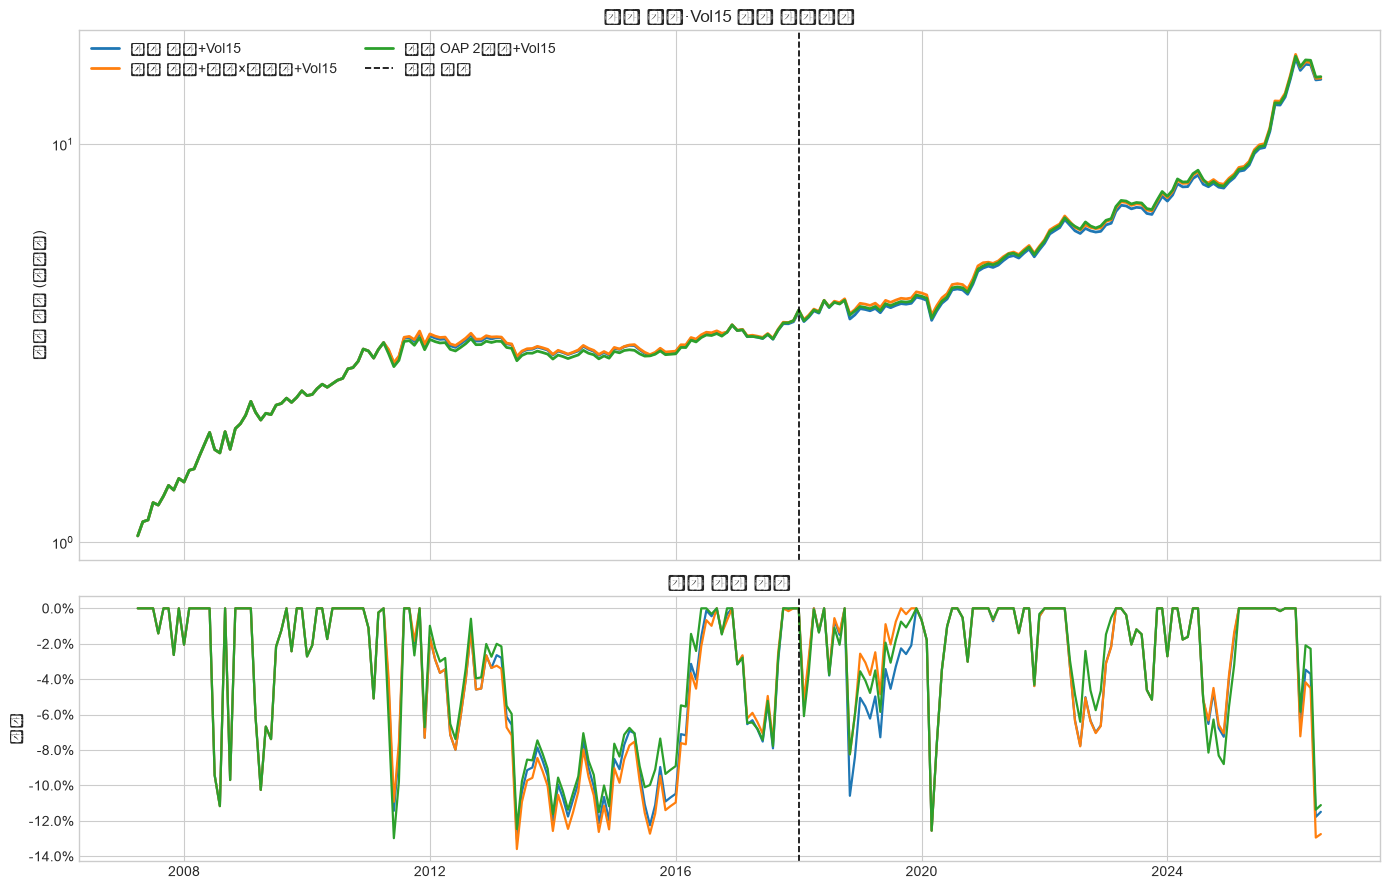

In [8]:
from strategies.core.regime_research import StrategyConfig, compute_regime_signals, load_macro_data, load_monthly_asset_returns, run_backtest
from strategies.stage04_ml_feedback.market_structure_robustness import run_factor_vol_target

macro, _ = load_macro_data()
asset_returns, _ = load_monthly_asset_returns(refresh=False)
signals = compute_regime_signals(macro, asset_returns)
defensive = run_backtest(asset_returns, signals, StrategyConfig(), mode="proposed")

def load_factor(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame["month"] = pd.PeriodIndex(frame["month"], freq="M")
    return frame.set_index("month")

existing_factor = load_factor(RESULTS / "market_structure_loss3_composite_domestic_factor.csv")
proxy_factor = load_factor(RESULTS / "market_structure_loss3_composite_plus_index_volume_domestic_factor.csv")
existing_bt = run_factor_vol_target(asset_returns, signals, defensive, existing_factor, max_shift=0.15, target_vol=0.15)
proxy_bt = run_factor_vol_target(asset_returns, signals, defensive, proxy_factor, max_shift=0.20, target_vol=0.15)

plot_returns = pd.DataFrame({
    "기존 구조+Vol15": existing_bt["return"],
    "기존 구조+지수×거래량+Vol15": proxy_bt["return"],
    "선택 OAP 2개월+Vol15": pd.Series(selected_bt["return"].to_numpy(), index=pd.PeriodIndex(selected_bt.index, freq="M")),
}).dropna()
nav = (1 + plot_returns).cumprod()
drawdown = nav.div(nav.cummax()).sub(1)
plot_index = plot_returns.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for column in nav:
    axes[0].plot(plot_index, nav[column], label=column, lw=2)
    axes[1].plot(plot_index, drawdown[column], label=column, lw=1.6)
for ax in axes:
    ax.axvline(pd.Timestamp("2018-01-01"), color="black", ls="--", lw=1.2, label="잠금 시작" if ax is axes[0] else None)
axes[0].set_yscale("log")
axes[0].set_ylabel("누적 자산 (로그축)")
axes[0].legend(ncol=2)
axes[0].set_title("동일 비용·Vol15 기준 누적성과")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_ylabel("낙폭")
axes[1].set_title("고점 대비 낙폭")
plt.tight_layout()
plt.show()

## 10. 하위기간 안정성

한 번의 전체기간 수치가 특정 위기나 강세장에만 의존하는지 보기 위해 네 구간으로 나눕니다.

In [9]:
SUBPERIODS = [
    "subperiod_2007_2012",
    "subperiod_2013_2017",
    "subperiod_2018_2021",
    "subperiod_2022_2026",
]
sub = comparison[
    comparison["Period"].isin(SUBPERIODS)
    & comparison["Strategy"].isin(["ExistingStructureVol15", "SelectedMediumHorizonOAPVol15"])
].copy()
sub_table = sub.pivot(index="Period", columns="Strategy", values=["CAGR", "Sharpe", "MDD"])
sub_table = sub_table.reindex(SUBPERIODS)
display(sub_table.style.format({
    (metric, strategy): ("{:.2%}" if metric in {"CAGR", "MDD"} else "{:.3f}")
    for metric in ["CAGR", "Sharpe", "MDD"]
    for strategy in ["ExistingStructureVol15", "SelectedMediumHorizonOAPVol15"]
}))

2007-2012에는 선택 OAP 전략이 기존 구조 전략보다 나빴습니다. 2013-2017과 2018-2021에는 개선이 비교적 명확했고, 2022-2026에는 CAGR과 MDD가 조금 좋아지는 대신 Sharpe가 소폭 낮았습니다. 즉 모든 국면에서 지배적인 신호는 아닙니다.

## 11. `지수×거래량` 대용치와 합성 방식 비교

동일 기간에서 `지수×거래량` 단독 추가, OAP 공동학습, 중기 오버레이, 위험위원회를 비교합니다. 공동학습은 Sharpe가 가장 높고, 중기 오버레이는 CAGR·MDD의 균형이 가장 좋으며, 위험위원회는 전체 CAGR을 우선하는 후보입니다.

C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\2462427026.py:16: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\2462427026.py:16: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  plt.tight_layout()
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


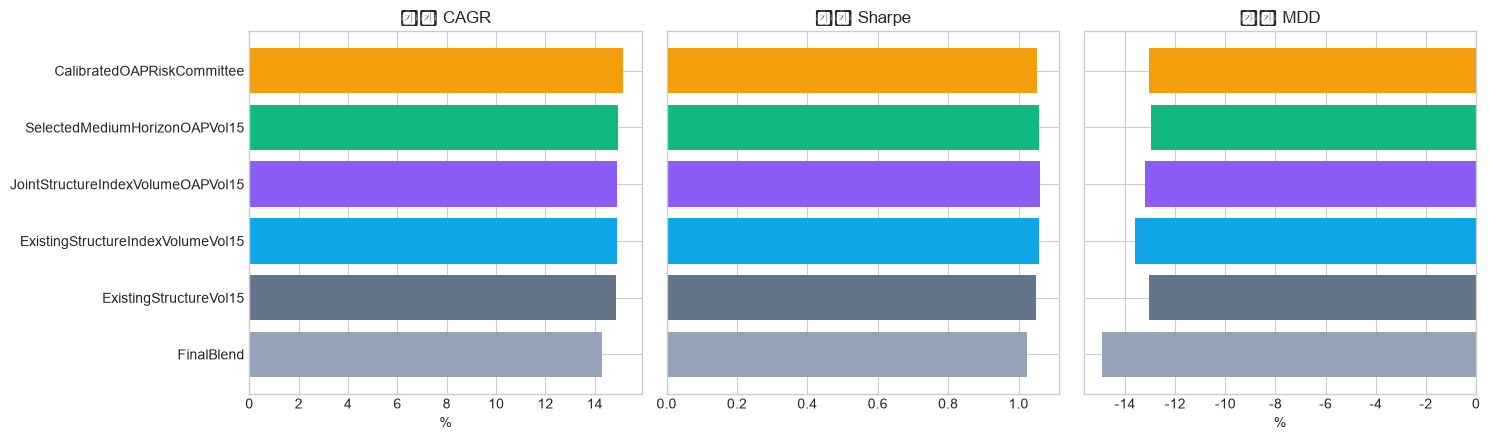

In [10]:
full = comparison[(comparison["Period"] == "full_2007_2026") & comparison["Strategy"].isin(KEY_STRATEGIES)].copy()
full = full.set_index("Strategy").reindex(KEY_STRATEGIES)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["#94A3B8", "#64748B", "#0EA5E9", "#8B5CF6", "#10B981", "#F59E0B"]
axes[0].barh(full.index, 100 * full["CAGR"], color=colors)
axes[0].set_title("전체 CAGR")
axes[0].set_xlabel("%")
axes[1].barh(full.index, full["Sharpe"], color=colors)
axes[1].set_title("전체 Sharpe")
axes[2].barh(full.index, 100 * full["MDD"], color=colors)
axes[2].set_title("전체 MDD")
axes[2].set_xlabel("%")
for ax in axes[1:]:
    ax.tick_params(labelleft=False)
plt.tight_layout()
plt.show()

## 12. 거래비용 강건성

정상 비용의 0.5배, 1배, 2배, 3배에서 같은 규칙을 다시 실행합니다. 비용을 높였을 때 우위가 즉시 사라진다면 회전율에 의존한 착시일 수 있습니다.

C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\234390167.py:20: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\234390167.py:20: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\234390167.py:20: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\234390167.py:20: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\234390167.py:20: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\234390167.py:20: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) Arial.
  plt.tight_layout()
C

D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 4439

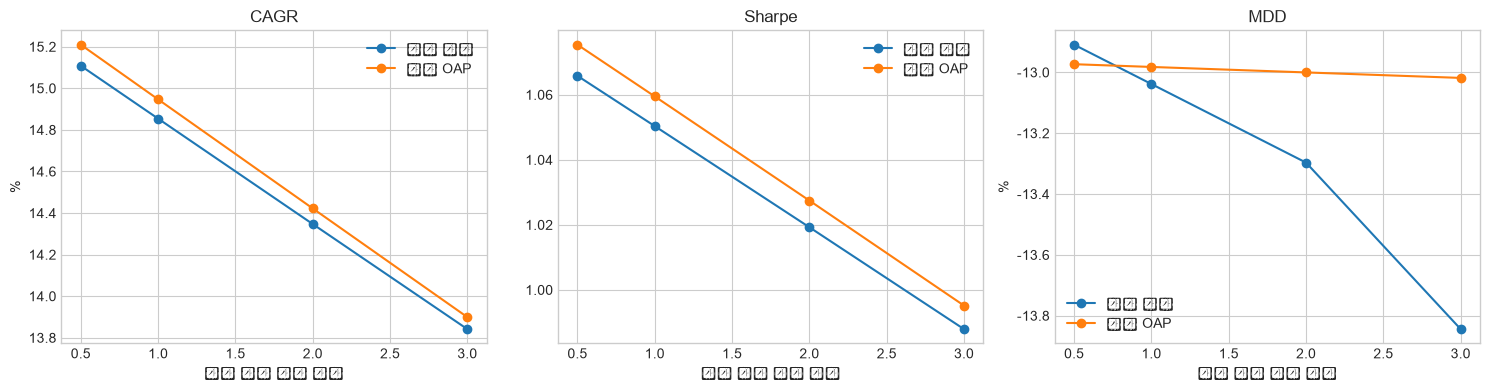

,Period,Strategy,CAGR,Sharpe,MDD,AvgTurnover
60,cost_3.0x_full,ExistingStructureVol15,13.84%,0.988,-13.84%,0.118
61,cost_3.0x_locked,ExistingStructureVol15,16.53%,1.123,-12.78%,0.133
78,cost_3.0x_full,SelectedMediumHorizonOAPVol15,13.90%,0.995,-13.02%,0.122
79,cost_3.0x_locked,SelectedMediumHorizonOAPVol15,16.55%,1.132,-12.78%,0.143


In [11]:
cost_view = costs[
    costs["Strategy"].isin(["ExistingStructureVol15", "SelectedMediumHorizonOAPVol15"])
    & costs["Period"].str.endswith("_full")
].copy()
cost_view["비용배수"] = cost_view["Period"].str.extract(r"cost_([0-9.]+)x")[0].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for strategy, group in cost_view.groupby("Strategy"):
    group = group.sort_values("비용배수")
    label = "기존 구조" if strategy == "ExistingStructureVol15" else "선택 OAP"
    axes[0].plot(group["비용배수"], 100 * group["CAGR"], marker="o", label=label)
    axes[1].plot(group["비용배수"], group["Sharpe"], marker="o", label=label)
    axes[2].plot(group["비용배수"], 100 * group["MDD"], marker="o", label=label)
axes[0].set_title("CAGR"); axes[0].set_ylabel("%")
axes[1].set_title("Sharpe")
axes[2].set_title("MDD"); axes[2].set_ylabel("%")
for ax in axes:
    ax.set_xlabel("정상 비용 대비 배수")
    ax.legend()
plt.tight_layout()
plt.show()

cost_3x = costs[
    costs["Period"].isin(["cost_3.0x_full", "cost_3.0x_locked"])
    & costs["Strategy"].isin(["ExistingStructureVol15", "SelectedMediumHorizonOAPVol15"])
][["Period", "Strategy", "CAGR", "Sharpe", "MDD", "AvgTurnover"]]
display(cost_3x.style.format({"CAGR": "{:.2%}", "Sharpe": "{:.3f}", "MDD": "{:.2%}", "AvgTurnover": "{:.3f}"}))

3배 비용에서도 선택 OAP 전략은 기존 구조+Vol15보다 전체 CAGR·Sharpe·MDD가 높고, 잠금구간에서는 MDD가 같으면서 CAGR·Sharpe가 높습니다. 효과가 매우 크지는 않지만 정상 비용 하나에만 의존하지는 않습니다.

## 13. 예측력과 통계적 불확실성

포트폴리오 성과가 좋아도 위험사건 예측 자체가 안정적이라는 뜻은 아닙니다. 잠금 AUC와 블록 부트스트랩을 함께 확인합니다.

In [12]:
prediction = pd.DataFrame(validation["medium_horizon_prediction"]).T
prediction.index = ["보정 2007-2017", "잠금 2018-2026"]
prediction = prediction[["observations", "events", "event_rate", "roc_auc", "average_precision", "brier_score", "recall_at_top_20pct", "precision_at_top_20pct"]]
display(prediction.style.format({
    "observations": "{:.0f}", "events": "{:.0f}", "event_rate": "{:.1%}",
    "roc_auc": "{:.3f}", "average_precision": "{:.3f}", "brier_score": "{:.3f}",
    "recall_at_top_20pct": "{:.1%}", "precision_at_top_20pct": "{:.1%}",
}))

boot = validation["bootstrap_vs_existing_structure_vol15"]["SelectedMediumHorizonOAPVol15"]
bootstrap_table = pd.DataFrame({
    "값": [
        boot["simulations"], boot["block_length"], boot["probability_sharpe_improves"],
        boot["sharpe_delta_p05"], boot["sharpe_delta_median"], boot["sharpe_delta_p95"],
    ]
}, index=["시뮬레이션", "블록 길이(개월)", "Sharpe 개선 확률", "Sharpe 차이 5%", "Sharpe 차이 중앙값", "Sharpe 차이 95%"])
display(bootstrap_table)

,observations,events,event_rate,roc_auc,average_precision,brier_score,recall_at_top_20pct,precision_at_top_20pct
보정 2007-2017,91,5,5.5%,0.379,0.065,0.196,20.0%,5.3%
잠금 2018-2026,102,10,9.8%,0.757,0.315,0.219,40.0%,19.0%


,값
시뮬레이션,5000.000000
블록 길이(개월),6.000000
Sharpe 개선 확률,0.735200
Sharpe 차이 5%,-0.040335
Sharpe 차이 중앙값,0.025579
Sharpe 차이 95%,0.094066


보정구간 사건은 5건뿐이고 AUC도 0.379입니다. 잠금 AUC 0.757은 긍정적이지만 잠금 사건도 10건에 불과합니다. Sharpe 차이의 5~95% 구간은 약 -0.040~+0.094로 0을 포함합니다. 따라서 “백테스트상 다목적 개선”은 맞지만 “통계적으로 확정된 알파”라고 표현해서는 안 됩니다.

## 14. 특징 가용성과 OAP 합성지표

초기 워밍업 이후 각 특징이 얼마나 채워졌는지 확인합니다. 거래량 장기추세처럼 더 긴 이력이 필요한 특징은 초반 결측이 존재하며, walk-forward 모델은 학습 시점별로 이를 처리합니다.

C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\571529052.py:6: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\571529052.py:6: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\571529052.py:6: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\571529052.py:6: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\571529052.py:6: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\571529052.py:6: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC_1M\AppData\Local\Temp\ipykernel_6956\571529052.py:6: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users

D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph

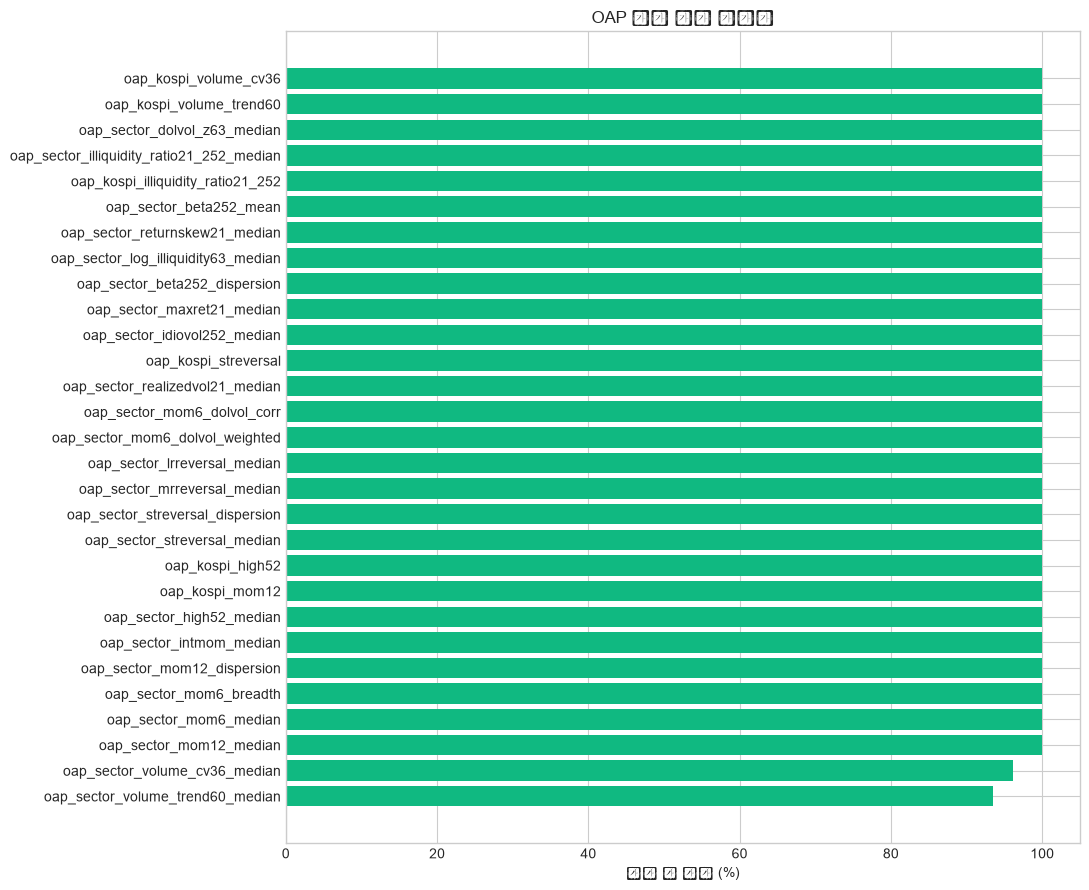

D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52285 (\N{HANGUL SYLLABLE CANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 5

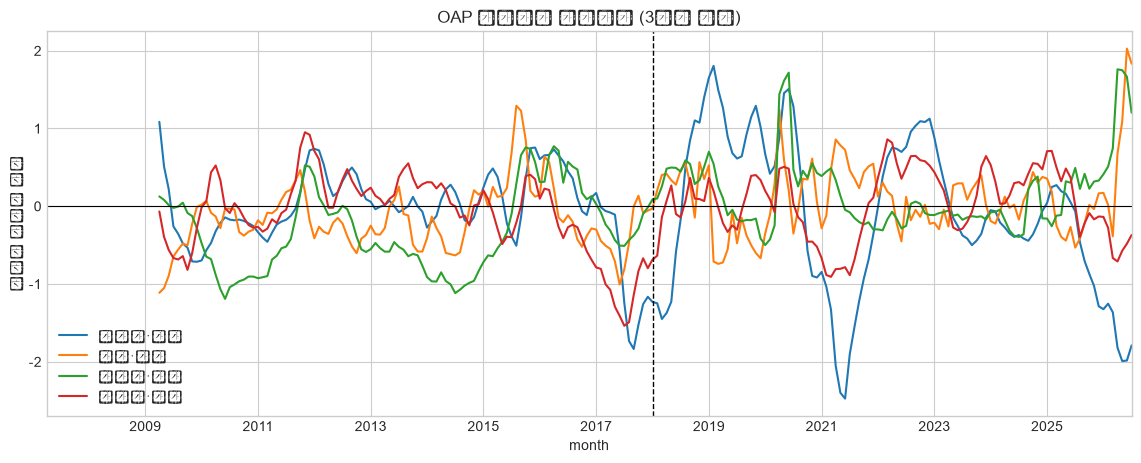

In [13]:
coverage = features.notna().mean().sort_values()
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(coverage.index, 100 * coverage.values, color=np.where(coverage.values >= 0.8, "#10B981", "#F59E0B"))
ax.set_xlabel("가용 월 비율 (%)")
ax.set_title("OAP 입력 특징 가용성")
plt.tight_layout()
plt.show()

plot_composites = composites.copy()
plot_composites.columns = ["모멘텀·추세", "반전·쏠림", "저위험·꼬리", "유동성·활동"]
ax = plot_composites.rolling(3, min_periods=1).mean().plot(figsize=(14, 5), lw=1.5)
ax.axvline(pd.Timestamp("2018-01-01"), color="black", ls="--", lw=1)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("OAP 스트레스 합성지표 (3개월 평균)")
ax.set_ylabel("과거창 표준화 점수")
plt.show()

## 15. 선택이 만들어진 보정 그리드

목표기간과 손실 임계값, 최대 방어 이동을 2017년까지의 보정구간에서만 비교했습니다. 기존 구조+Vol15의 CAGR·Sharpe·MDD를 모두 넘는 후보만 남기고 Calmar, Sharpe, CAGR 순으로 선택했습니다.

In [14]:
grid_display = medium_grid[["target", "horizon", "max_shift", "events", "CAGR", "Sharpe", "MDD", "Calmar"]].copy()
grid_display["selected"] = (
    (grid_display["target"] == validation["selection"]["medium_horizon_target"])
    & np.isclose(grid_display["max_shift"], validation["selection"]["medium_horizon_shift"])
)
grid_display = grid_display.sort_values(["selected", "Calmar", "Sharpe"], ascending=[False, False, False])
display(grid_display.style.format({"max_shift": "{:.0%}", "CAGR": "{:.2%}", "Sharpe": "{:.3f}", "MDD": "{:.2%}", "Calmar": "{:.3f}"}).background_gradient(subset=["Calmar"], cmap="YlGn"))

,target,horizon,max_shift,events,CAGR,Sharpe,MDD,Calmar,selected
7,oap_path_loss_2m_5,2,20%,9,12.67%,0.931,-12.98%,0.976,True
3,oap_path_loss_2m_4,2,20%,10,12.67%,0.931,-12.98%,0.976,False
6,oap_path_loss_2m_5,2,15%,9,12.64%,0.928,-12.98%,0.974,False
2,oap_path_loss_2m_4,2,15%,10,12.64%,0.928,-12.98%,0.974,False
11,oap_path_loss_3m_5,3,20%,13,12.62%,0.929,-12.98%,0.972,False
10,oap_path_loss_3m_5,3,15%,13,12.59%,0.925,-12.98%,0.969,False
5,oap_path_loss_2m_5,2,10%,9,12.58%,0.924,-12.98%,0.969,False
1,oap_path_loss_2m_4,2,10%,10,12.58%,0.924,-12.98%,0.969,False
9,oap_path_loss_3m_5,3,10%,13,12.54%,0.922,-12.98%,0.966,False
4,oap_path_loss_2m_5,2,5%,9,12.48%,0.919,-12.98%,0.961,False


## 16. 최종 해석과 사용 권고

- **균형형 기본 후보:** `SelectedMediumHorizonOAPVol15`
- **최대 Sharpe 우선:** `JointStructureIndexVolumeOAPVol15`
- **최대 CAGR 우선:** `CalibratedOAPRiskCommittee`
- 단순 위험확률 선형합성은 기존 신호를 희석해 채택하지 않습니다.
- `지수×거래량`은 유용한 대용치이지만 실제 거래대금과 같지 않으므로 상대변화 신호로만 해석합니다.
- SPY·VIX는 국장 타깃 OAP 추가효과를 분리하기 위해 제외했습니다.
- 설정을 이제 고정하고 전진 관찰하거나, 시점별 KOSPI200 구성종목·재무데이터로 별도 검증하는 것이 다음 단계입니다.

가장 중요한 한계는 후보 수에 비해 희귀 손실사건이 적다는 점입니다. 현재 결과는 실전 채택의 확정판이 아니라, **추가 검증할 가치가 있는 소폭 개선 후보**로 보는 것이 적절합니다.

## 17. 결과물 ZIP 저장·다운로드

아래 셀은 최신 OAP 결과와 실행 소스를 하나의 ZIP으로 묶습니다. Colab에서 자동 다운로드까지 원하면 `DOWNLOAD_RESULTS = True`로 바꾸세요.

In [15]:
export_zip = PROJECT_ROOT / "artifacts/bundles/openassetpricing_latest_results.zip"
export_members = [
    *sorted(RESULTS.glob("openassetpricing_*")),
    RESULTS / "hard_crash_features.csv",
    RESULTS / "market_structure_composites.csv",
    RESULTS / "market_structure_loss3_composite_domestic_factor.csv",
    RESULTS / "market_structure_loss3_composite_plus_index_volume_domestic_factor.csv",
    PROJECT_ROOT / "strategies/stage05_openassetpricing/openassetpricing_signal_experiment.py",
]
with zipfile.ZipFile(export_zip, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=9) as archive:
    for path in export_members:
        if path.is_file():
            archive.write(path, path.relative_to(PROJECT_ROOT).as_posix())
print("결과 ZIP:", export_zip)

DOWNLOAD_RESULTS = False
if IN_COLAB and DOWNLOAD_RESULTS:
    from google.colab import files
    files.download(str(export_zip))

결과 ZIP: D:\Programming\python_example\RegimeDecisionTest\artifacts\bundles\openassetpricing_latest_results.zip
